## Lab 3: Uniform Manifold Approximation and Projection (UMAP) for Dimensionality Reduction
*Suggested time: 25-30 minutes*

This lab walks us



Resource: [UMAP Documentation](https://umap-learn.readthedocs.io/en/latest/index.html)

```text
[ High-Dimensional Data (X) ]
              |
              v
[ STAGE 1: GRAPH CONSTRUCTION (Topology) ]
|
|-- [ 1. k-Nearest Neighbors (k-NN) ]
|      (Find local neighbors for each point)
|
|-- [ 2. Local Metric Scaling ]
|      (Distance to 1st neighbor = 0; normalized by density)
|
|-- [ 3. Fuzzy Simplicial Set ]
|      (Connect points with "fuzzy" probabilities)
|
|-- [ 4. Symmetrization ]
|      (Ensure point A likes point B as much as B likes A)
|
|      [ Result: High-Dim Weighted Graph ]
              |
              v
[ STAGE 2: LAYOUT OPTIMIZATION (Embedding) ]
|
|-- [ 1. Initialization ]
|      (Typically Spectral Embedding / Graph Laplacian)
|
|-- [ 2. Cross-Entropy Minimization ]
|      (Align the Low-Dim graph with the High-Dim graph)
|
|-- [ 3. Stochastic Gradient Descent (SGD) ]
|      (Attractive forces pull neighbors; Repulsive forces push others)
|
|      [ Result: Low-Dim Projection (Y) ]
```

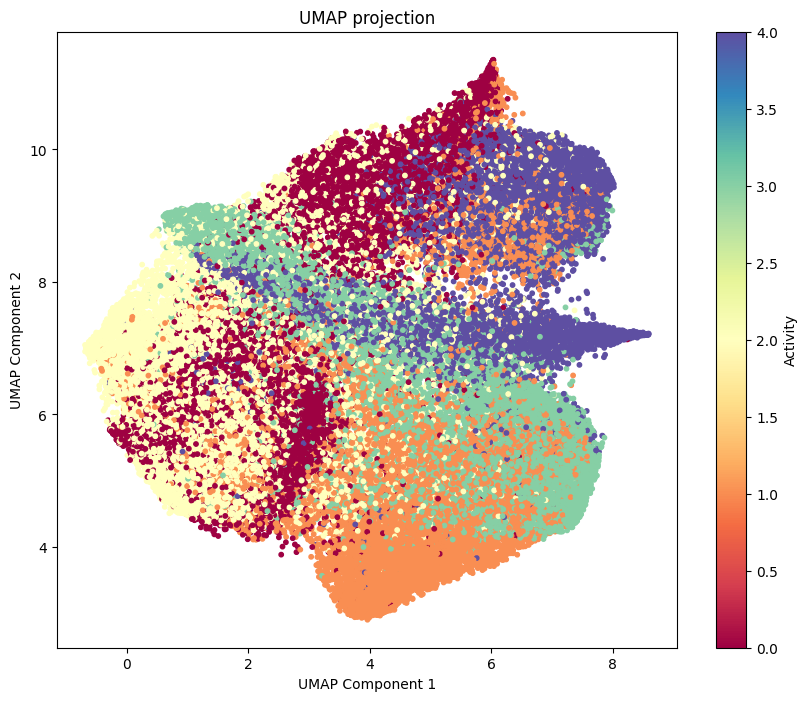

In [0]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import umap

X, y = make_classification(n_samples=100000, n_features=20, n_classes=5, n_informative=5, random_state=0)
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2)

umap_model = umap.UMAP(n_neighbors=15, n_components=2, random_state=42, min_dist=0.0, n_jobs=1)
X_train_umap = umap_model.fit_transform(X_train)
y_train
# Plot the UMAP result
plt.figure(figsize=(10, 8))
plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_train, cmap='Spectral', s=10)
plt.colorbar(label="Activity")
plt.title("UMAP projection")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.show()

In [0]:
!pip install -q umap-learn seaborn palmerpenguins

In [3]:
!pip install -q palmerpenguins

UMAP (Uniform Manifold Approximation and Projection) effectively projects high-dimensional embeddings into 2D, frequently confirming dataset distribution by creating distinct, interpretable clusters that represent local neighborhoods and global structures. While excellent for visualization, it is a non-linear, stochastic dimensionality reduction technique and may distort exact distances, meaning clusters in 2D do not technically prove the exact underlying distribution, though they provide a reliable approximation of topological structures

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding shape after transform (333, 2)


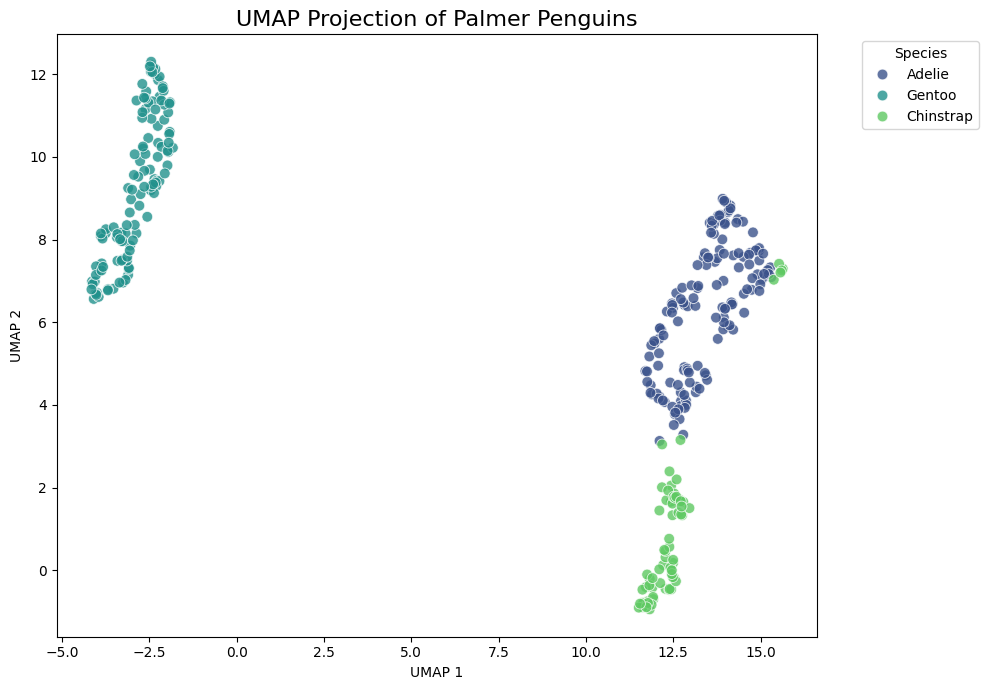

In [4]:
import umap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from palmerpenguins import load_penguins

# 1. Load the "Relatable" Dataset
penguins = load_penguins()

# 2. Preprocessing
# Drop rows with missing values (real-world data has NaNs!)
penguins = penguins.dropna()

# Select numeric features: Bill length, Bill depth, Flipper length, Body mass
data = penguins[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]

# 3. Scaling is MANDATORY for UMAP
# Because 'body_mass_g' is in the thousands while 'bill_depth' is < 25.
scaled_data = StandardScaler().fit_transform(data)

# 4. Fit UMAP
# n_neighbors: balances local vs global structure (15 is a good default)
# min_dist: how tightly points are packed (0.1 is standard)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(scaled_data)

print ('Embedding shape after transform', embedding.shape)

# 5. Visualization
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=penguins.species,
    palette='viridis',
    s=60,
    alpha=0.8
)

plt.title('UMAP Projection of Palmer Penguins', fontsize=16)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Shape of synthetic data (X): (1000, 20)
Shape of synthetic labels (y): (1000,)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


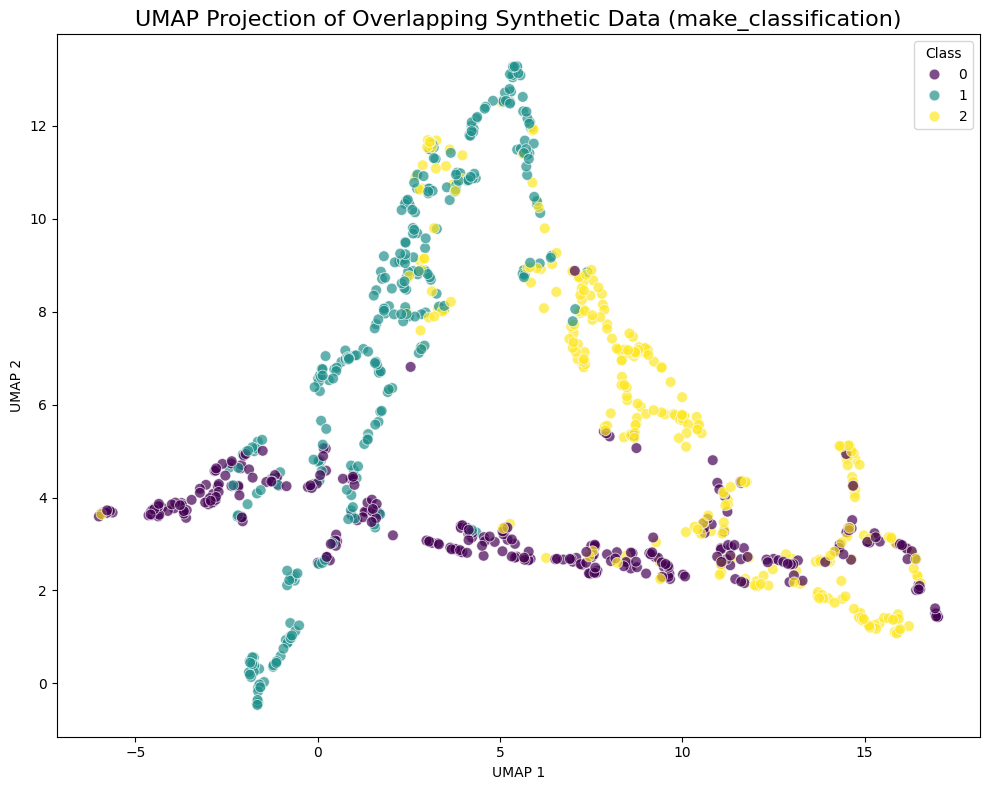

In [1]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification

# Create a synthetic dataset with intentionally overlapping classes
# n_informative: fewer informative features lead to more ambiguity
# n_redundant, n_repeated: adding more noise/redundancy contributes to overlap
# class_sep: a lower value explicitly reduces the separation between classes
X_overlap, y_overlap = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=2,
    n_redundant=8,
    n_repeated=10,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=0.5, # Significantly lower class separation
    random_state=42
)

print(f"Shape of synthetic data (X): {X_overlap.shape}")
print(f"Shape of synthetic labels (y): {y_overlap.shape}")

# Apply UMAP to the overlapping data
# Using default n_neighbors=15, min_dist=0.1 which are good general parameters.
reducer_overlap = umap.UMAP(n_components=2, random_state=42)
embedding_overlap = reducer_overlap.fit_transform(X_overlap)

# Plot the UMAP projection to visualize the overlapping clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=embedding_overlap[:, 0],
    y=embedding_overlap[:, 1],
    hue=y_overlap,
    palette='viridis',
    s=60,
    alpha=0.7
)
plt.title('UMAP Projection of Overlapping Synthetic Data (make_classification)', fontsize=16)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='Class')
plt.tight_layout()
plt.show()